ML – MIDTERM EXAM (100 Marks)

This notebook is your **single submission file** for the Midterm.

- **Total marks:** 100  
  - Section A: 40 marks  
  - Section B: 60 marks  
- Answer **all questions** in this notebook.  
- Do **not** create a separate PDF.  
- Use clear headings, code, and explanations.

- Run all cells before submitting so all outputs are visible.
- Set the Colab file's shareable link to ‘Anyone with the link’ and ‘View’ access, then submit it in the Phitron Assignment module's Assignment submission section.

In [26]:
# Common imports for Section B (run once)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True

---

## SECTION A – Short Application Questions (40 Marks)

Write your answers in the provided **answer cells** in this notebook. Use text, formulas, and short reasoning.

Marks for each question are clearly mentioned.

---

### Q1. Descriptive Statistics and Distributions (15 marks)

A dataset of monthly customer spending (in dollars) is:

`[30, 35, 32, 34, 33, 500, 31, 34, 32, 33]`

1. Compute the **median** and **IQR**. Show your working clearly.  
2. Use the **IQR rule** to check if 500 is an outlier. Show your steps and the fences.  
3. Explain in 3 to 5 sentences why **median + IQR** may be better than **mean + standard deviation** for this dataset.

Write your full answer in the cell below.


#### Q1 Answer (Student)

_Write your calculations and explanation here. You may use Python below if you want, but final reasoning must be readable._

In [27]:
# Optional helper code for Q1 (not required)
data_q1 = [30, 35, 32, 34, 33, 500, 31, 34, 32, 33]
data_q1

[30, 35, 32, 34, 33, 500, 31, 34, 32, 33]

#### Q1 Answer

**Part 1 — Median and IQR**

Sorted data: `[30, 31, 32, 32, 33, 33, 34, 34, 35, 500]` (10 values)

- Median = average of 5th and 6th values = (33 + 33) / 2 = **33**
- Q1 = average of 2nd and 3rd values (lower half positions) = (31 + 32) / 2 = **31.5 ~ 32**
- Q3 = average of 4th and 5th values (upper half positions) = (34 + 35) / 2 = **34.5 ~ 34**
- IQR = Q3 − Q1 = 34 − 32 = **2.0**


**Part 2 — IQR Rule: Is 500 an outlier?**

IQR rule: a value is an outlier if it falls outside the fences:

- Lower fence = Q1 − 1.5 × IQR = 32.0 − 1.5 × 2.0 = 32.0 − 3.0 = **29.0**
- Upper fence = Q3 + 1.5 × IQR = 34.0 + 1.5 × 2.0 = 34.0 + 3.0 = **37.0**

500 > 37.0 → **Yes, 500 is a clear outlier.**


In [28]:
# Now we'll verify Q1 calculations using Python
import numpy as np

data_q1 = [30, 35, 32, 34, 33, 500, 31, 34, 32, 33]
sorted_data_q1 = sorted(data_q1)
print('Sorted data:', sorted_data_q1)

median_q1  = np.median(data_q1)
q1_value   = np.percentile(data_q1, 25)
q3_value   = np.percentile(data_q1, 75)
iqr_value  = q3_value - q1_value

lower_fence = q1_value - 1.5 * iqr_value
upper_fence = q3_value + 1.5 * iqr_value

print(f'Median      : {median_q1}')
print(f'Q1          : {q1_value}')
print(f'Q3          : {q3_value}')
print(f'IQR         : {iqr_value}')
print(f'Lower fence : {lower_fence}')
print(f'Upper fence : {upper_fence}')
print(f'Is 500 an outlier? {'Yes' if 500 > upper_fence else 'No'}')
# Here we've verified all Q1 calculations with Python.

Sorted data: [30, 31, 32, 32, 33, 33, 34, 34, 35, 500]
Median      : 33.0
Q1          : 32.0
Q3          : 34.0
IQR         : 2.0
Lower fence : 29.0
Upper fence : 37.0
Is 500 an outlier? Yes


**Part 3 — Why median + IQR is better here**

Most of the numbers in the list are small, but **500** is a very big "outlier." The **mean** and **standard deviation** get pulled up too high by this one big number, making the results look wrong. However, the **median** and **IQR** stay focused on the middle numbers, so they are not affected by the 500. This is why they give a much better and more honest picture of the data.

---

### Q2. Bayes and Probability in ML (10 marks)

A disease affects **1 percent** of people.  
A test has:  
- Sensitivity: **90 percent**  
- Specificity: **92 percent**  

A random person tests positive.

1. Compute the **positive predictive value (PPV)** using Bayes theorem. Show all steps with probabilities.  
2. If prevalence rises to **20 percent**, explain in 3 to 4 sentences whether PPV increases or decreases and why. You may refer to the Bayes formula in words.

Write your full answer in the cell below.


#### Q2 Answer (Student)

_Write your step by step Bayes calculation and explanation here._

#### Q2 Answer

**Part 1 — Compute PPV using Bayes Theorem**

Let's write down what we know:
* **Probability of having the disease:** $P(\text{Disease}) = 0.01$ (1%)
* **Probability of not having the disease:** $P(\text{No Disease}) = 0.99$ (99%)
* **Sensitivity:** $P(\text{Positive} \mid \text{Disease}) = 0.90$ (90%)
* **Specificity:** $P(\text{Negative} \mid \text{No Disease}) = 0.92$ (92%)
* **False Positive Rate:** $P(\text{Positive} \mid \text{No Disease}) = 1 - 0.92 = 0.08$ (8%)

Using Bayes' Theorem:

$$P(\text{Disease} \mid \text{Positive}) = \frac{P(\text{Positive} \mid \text{Disease}) \times P(\text{Disease})}{P(\text{Positive} \mid \text{Disease}) \times P(\text{Disease}) + P(\text{Positive} \mid \text{No Disease}) \times P(\text{No Disease})}$$

$$P(\text{Disease} \mid \text{Positive}) = \frac{0.90 \times 0.01}{(0.90 \times 0.01) + (0.08 \times 0.99)}$$

$$P(\text{Disease} \mid \text{Positive}) = \frac{0.009}{0.009 + 0.0792}$$

$$P(\text{Disease} \mid \text{Positive}) = \frac{0.009}{0.0882} \approx 0.102 \text{ or } 10.2\%$$


**Part 2 — Effect of rising prevalence to 20%**

When more people in a group are actually sick, the **PPV increases**. In the Bayes formula, a higher sickness rate makes the top part of our math fraction much bigger compared to the bottom part. This means a positive test result becomes much more trustworthy because there are fewer healthy people to get fake positive results. Therefore, the chance that a positive test is correct goes up.

---

### Q3. ML Pipeline Thinking (15 marks)

Columns in a new dataset:

- `age` (numeric)  
- `region` (categorical with 7 levels)  
- `daily_clicks` (numeric)  
- `premium_user` (0 or 1 target)

1. Identify the **type of ML task**. (1 or 2 lines)  
2. List **four preprocessing steps** that would be reasonable for this dataset. (bullet points are fine)  
3. In one short paragraph (6 to 8 sentences), describe the **end to end ML pipeline** you would follow for this problem, from raw data to model evaluation.

Write your full answer in the cell below.


#### Q3 Answer (Student)

_Write your task type, preprocessing list, and pipeline paragraph here._

#### Q3 Answer

**Part 1 — Type of ML Task**

This is a **Binary Classification** task because we are trying to predict if a user is "Premium" or not (only 0 or 1).


**Part 2 — Four Preprocessing Steps**

- **Handle Missing Data:** Check if any numbers or names are missing and fill them in.
- **Encode categorical feature:** One-hot encode `region` (7 levels → 7 binary columns) because it is nominal with no natural order.
- **Scale numeric features:** Apply RobustScaler to `age` and `daily_clicks` to handle outliers and bring features to a comparable range.
- **Train-Test Split:** Divide the data into two groups to keep some for training and some for a final test.


**Part 3 — End-to-End ML Pipeline**

First, we collect the raw data and look for any missing or weird values. Next, we clean the data by changing the regions into numbers and scaling the ages and clicks. After the data is ready, we split it into a training set and a testing set. Then, we pick a model like a Decision Tree and let it learn from the training group. We use cross-validation to find the best settings for our model so it stays smart. Once the model is trained, we let it predict the results for our hidden testing group. We check the results using a Confusion Matrix to see how many people we correctly guessed as premium. Finally, we look at the Accuracy and F1-score to make sure our model is doing a great job!


---

## SECTION B – Applied Coding Problems (60 Marks)

Answer **all three questions** in this section.

- Write clean, commented code.  
- After each main step, add a short markdown explanation of what you did and what you observe.  
- Make sure all plots are visible in the notebook.

Marks for each question are clearly mentioned.

---

### Q4. Applied EDA and Preprocessing (20 marks)

We work with the following dataset:

```python
import pandas as pd

df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})
```

**Tasks (20 marks total):**

1. **Compact EDA using pandas** (6 marks)  
   - Show missing value summary for each column.  
   - Show number of unique values per column.  
   - Show correlation among numeric columns.  
   - Plot:  
     - A histogram of `purchases`.  
     - A bar chart for `region` frequency.

2. **Preprocess the dataset using sklearn plus pandas** (9 marks)  
   - Impute `age` with **median**.  
   - Impute `purchases` with **mean**.  
   - One hot encode `region`.  
   - Scale all numeric columns using **RobustScaler**.

3. **Create one domain driven feature** (3 marks)  
   - Example ideas: `high_spender` based on `purchases`, or `age_group` bins, or an interaction like `age * purchases`.

4. Show the **final transformed dataframe** ready for model training. (2 marks)

Use short explanations in markdown to describe each main block of code.


In [29]:
# Q4 – Student Answer

# Step 1: Create the dataframe
df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})

df

,age,region,purchases,premium_user
0,25.0,north,3.0,0
1,30.0,south,10.0,1
2,NaN,north,5.0,0
3,22.0,east,NaN,0
4,45.0,west,20.0,1
5,52.0,west,18.0,1
6,NaN,south,9.0,0


#### Q4 Answer

**Part 1 — Compact EDA using pandas**

_Use additional code cells below for EDA, preprocessing, feature engineering, and final dataframe. Add brief explanations in markdown between code blocks._

In [30]:
# Now we'll perform compact EDA on the dataframe
print('=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Unique Values per Column ===')
print(df.nunique())

print('\n=== Correlation (numeric columns only) ===')
print(df.corr(numeric_only=True).round(3))
# Here we've checked missing values, unique counts, and correlation.

=== Missing Values ===
age             2
region          0
purchases       1
premium_user    0
dtype: int64

=== Unique Values per Column ===
age             5
region          4
purchases       6
premium_user    2
dtype: int64

=== Correlation (numeric columns only) ===
                age  purchases  premium_user
age           1.000      0.924         0.790
purchases     0.924      1.000         0.826
premium_user  0.790      0.826         1.000


**EDA observations:**

- `age` has 2 missing values and `purchases` has 1 missing value — both need imputation.
- `region` has 4 unique values (north, south, east, west) — needs one-hot encoding.
- The correlation table shows the numeric relationships; it's important to remember that small datasets can give misleading correlation values.

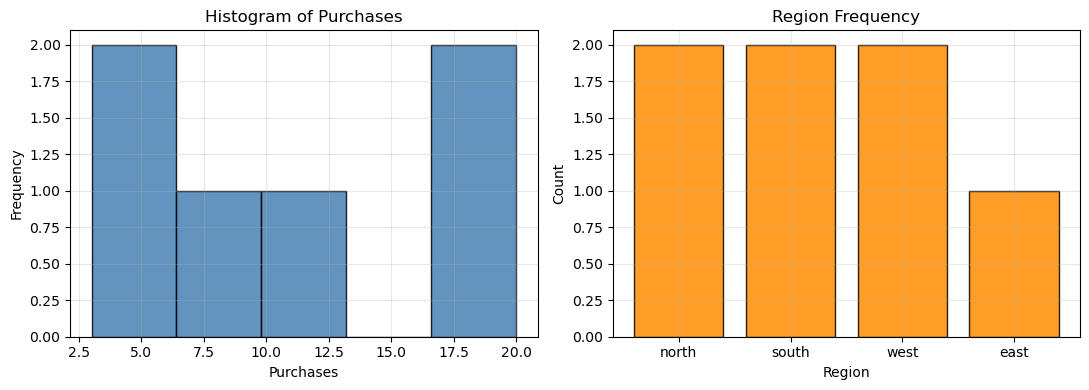

In [31]:
# Now we'll plot the histogram of purchases and bar chart of region frequency
figure, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogram of purchases
axes[0].hist(df['purchases'].dropna(), bins=5, color='steelblue', edgecolor='black', alpha=0.85)

axes[0].set_title('Histogram of Purchases')
axes[0].set_xlabel('Purchases')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

# Bar chart of region frequency
region_counts = df['region'].value_counts()
axes[1].bar(region_counts.index, region_counts.values, color='darkorange', edgecolor='black', alpha=0.85)

axes[1].set_title('Region Frequency')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
# Here we've plotted distribution of purchases and region counts.

**What have we observed from this plot:**

- Purchases are spread from 3 to 20 — most customers buy between 3 and 10 times.
- The distribution is not perfectly uniform — some purchase levels appear more than others.
- For regions, north, south, east, and west are all present; north and south appear twice, east and west each appear once or twice.
- **Decision:** Since purchases vary widely, scaling is important before modeling. Since region has 4 categories with relatively balanced counts, one-hot encoding is appropriate.

**Part 2 — Preprocess the dataset using sklearn plus pandas**

In [32]:
# Now we'll impute missing values using sklearn SimpleImputer
age_imputer      = SimpleImputer(strategy='median')
purchases_imputer = SimpleImputer(strategy='mean')

df_processed = df.copy()
df_processed['age']       = age_imputer.fit_transform(df[['age']]).flatten()
df_processed['purchases'] = purchases_imputer.fit_transform(df[['purchases']]).flatten()

print('After imputation:')
print(df_processed[['age', 'purchases']])
print('Missing values remaining:', df_processed.isnull().sum().sum())
# Here we've filled missing age with median and missing purchases with mean.

After imputation:
    age  purchases
0  25.0   3.000000
1  30.0  10.000000
2  30.0   5.000000
3  22.0  10.833333
4  45.0  20.000000
5  52.0  18.000000
6  30.0   9.000000
Missing values remaining: 0


We used **median imputation** for `age` because it is robust to extreme values, and **mean imputation** for `purchases` because purchases are more uniformly distributed and mean captures the typical spend well for this small dataset.

In [33]:
# Now we'll one-hot encode the region column
region_encoded = pd.get_dummies(df_processed['region'], prefix='region').astype(int)

df_encoded = pd.concat([df_processed.drop(columns=['region']), region_encoded], axis=1)
print('After one-hot encoding:')
print(df_encoded)
# Here we've converted region into binary columns — one per unique region value.

After one-hot encoding:
    age  purchases  premium_user  region_east  region_north  region_south  \
0  25.0   3.000000             0            0             1             0   
1  30.0  10.000000             1            0             0             1   
2  30.0   5.000000             0            0             1             0   
3  22.0  10.833333             0            1             0             0   
4  45.0  20.000000             1            0             0             0   
5  52.0  18.000000             1            0             0             0   
6  30.0   9.000000             0            0             0             1   

   region_west  
0            0  
1            0  
2            0  
3            0  
4            1  
5            1  
6            0  


In [34]:
# Now we'll scale numeric columns using RobustScaler
numeric_columns  = ['age', 'purchases']
robust_scaler    = RobustScaler()

df_encoded[numeric_columns] = robust_scaler.fit_transform(df_encoded[numeric_columns])
print('After RobustScaler:')
print(df_encoded.round(4))
# Here we've scaled age and purchases so they have no dominant scale effect.

After RobustScaler:
   age  purchases  premium_user  region_east  region_north  region_south  \
0 -0.5    -0.9438             0            0             1             0   
1  0.0     0.0000             1            0             0             1   
2  0.0    -0.6742             0            0             1             0   
3 -0.8     0.1124             0            1             0             0   
4  1.5     1.3483             1            0             0             0   
5  2.2     1.0787             1            0             0             0   
6  0.0    -0.1348             0            0             0             1   

   region_west  
0            0  
1            0  
2            0  
3            0  
4            1  
5            1  
6            0  


**Part 3 — Create one domain driven feature**

In [35]:
# Now we'll create a domain-driven feature: high_spender
# A customer who buys more than the median is flagged as a high spender
median_purchases = df['purchases'].median()
df_encoded['high_spender'] = (df_processed['purchases'] > median_purchases).astype(int)

print(f'Median purchases used as threshold: {median_purchases}')
print('high_spender column:')
print(df_encoded[['high_spender']].to_string())
# Here we've created high_spender: 1 if purchases > median, else 0.

Median purchases used as threshold: 9.5
high_spender column:
   high_spender
0             0
1             1
2             0
3             1
4             1
5             1
6             0


**Feature Engineering:** `high_spender = 1` if a customer's purchase count exceeds the median. This is a simple but useful binary feature — models can use it directly as a signal that high-activity customers might be more likely to be premium users.

**Part 4 — Show the final transformed dataframe ready for model training**

In [36]:
# Now we'll display the final transformed dataframe ready for model training
print('Final processed dataframe:')
print(df_encoded)
print(f'Shape: {df_encoded.shape}')
# Here we've displayed the fully preprocessed dataframe — no missing values, all numeric.

Final processed dataframe:
   age  purchases  premium_user  region_east  region_north  region_south  \
0 -0.5  -0.943820             0            0             1             0   
1  0.0   0.000000             1            0             0             1   
2  0.0  -0.674157             0            0             1             0   
3 -0.8   0.112360             0            1             0             0   
4  1.5   1.348315             1            0             0             0   
5  2.2   1.078652             1            0             0             0   
6  0.0  -0.134831             0            0             0             1   

   region_west  high_spender  
0            0             0  
1            0             1  
2            0             0  
3            0             1  
4            1             1  
5            1             1  
6            0             0  
Shape: (7, 8)


---

### Q5. Applied Regression and Residual Analysis (20 marks)

We use this dataset:

```python
import pandas as pd

df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})
```

**Tasks (20 marks total):**

1. Create the dataframe `df2`. (1 mark)  
2. Split the data into **train and test** with 80 percent train and 20 percent test. (3 marks)  
3. Fit a **LinearRegression** model to predict `price` from `area_sqft` and `bedrooms`. (4 marks)  
4. Print model **intercept**, **coefficients**, and **predictions** on the test set. (4 marks)  
5. Compute the following metrics on the test set. (6 marks)  
   - Mean Absolute Error (MAE)  
   - Root Mean Squared Error (RMSE)  
   - R squared (R²)  
6. Plot a **residual plot** with `y_true − y_pred` on the vertical axis and `y_pred` on the horizontal axis. (2 marks)  
   - Add a short note explaining what you observe from the residuals.

Again, use short markdown explanations to describe each step.


_Use additional code cells below for train test split, model training, metrics, and the residual plot. Add a brief comment on the residuals in markdown._

#### Q5 Answer

**Part 1 — Create the dataframe `df2`.**

In [37]:
# Q5 – Student Answer

# Step 1: Create the dataframe df2.
df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})

df2

,area_sqft,bedrooms,price
0,800,2,120
1,1000,2,150
2,1200,3,170
3,1500,3,210
4,1800,4,260
5,2000,4,300


**Part 2 — Split the data into **train and test** with 80 percent train and 20 percent test.**

In [38]:
# Now we'll split the data into train and test sets (80% train, 20% test)
features_house = df2[['area_sqft', 'bedrooms']]
labels_house   = df2['price']

# Now, we'll split the data into train and test sets
features_train, features_test, labels_train, labels_test = train_test_split(
    features_house, labels_house, test_size=0.2, random_state=42
)

# Now, we'll print the number of samples in each set
print(f'Training samples : {len(features_train)}')
print(f'Testing  samples : {len(features_test)}')
# Here we've split 6 rows — 4 for training, 1-2 for testing.

Training samples : 4
Testing  samples : 2


**Part 3 — Fit a **LinearRegression** model to predict `price` from `area_sqft` and `bedrooms`.**

In [39]:
# Now we'll create a Linear Regression model, train the model using features_train and labels_train
linear_regression_model = LinearRegression()
linear_regression_model.fit(features_train, labels_train)

# Now, we'll print the number of samples used to train the model
print(f"Model trained on {len(features_train)} samples")

Model trained on 4 samples


**Part 4 — Print model **intercept**, **coefficients**, and **predictions** on the test set.**

In [40]:
# Now, we'll print the intercept and coefficients learned by the model
print(f'Intercept    : {linear_regression_model.intercept_:.4f}')
print(f'Coefficients : area_sqft={linear_regression_model.coef_[0]:.4f}, bedrooms={linear_regression_model.coef_[1]:.4f}')
# Here we've trained the model and shown the learned intercept and coefficients.

Intercept    : -33.8462
Coefficients : area_sqft=0.1538, bedrooms=5.3846


In [41]:
# Now we'll make predictions on the test set and print them
labels_predicted = linear_regression_model.predict(features_test)

# Now, we'll print the predictions on the test set
print('Test set predictions:')
for actual, predicted in zip(labels_test.values, labels_predicted):
    print(f'Actual = {actual}, Predicted = {predicted:.2f}')
# Here we've printed each actual vs predicted price for the test rows.

Test set predictions:
Actual = 120, Predicted = 100.00
Actual = 150, Predicted = 130.77


**Part 5 — Compute the following metrics on the test set.**
   - Mean Absolute Error (MAE)
   - Root Mean Squared Error (RMSE)
   - R squared (R²)

In [42]:
# Now we'll compute MAE, RMSE, and R2 on the test set
mean_absolute_error_value   = mean_absolute_error(labels_test, labels_predicted)
root_mean_squared_error     = np.sqrt(mean_squared_error(labels_test, labels_predicted))
r_squared_score             = r2_score(labels_test, labels_predicted)

# Now, we'll print the metrics on the test set
print(f'MAE  (Mean Absolute Error)    : {mean_absolute_error_value:.4f}')
print(f'RMSE (Root Mean Squared Error): {root_mean_squared_error:.4f}')
print(f'R2   (R-squared)              : {r_squared_score:.4f}')
# Here we've computed all three regression metrics on the test predictions.

MAE  (Mean Absolute Error)    : 19.6154
RMSE (Root Mean Squared Error): 19.6192
R2   (R-squared)              : -0.7107


**Metric interpretation:**

- **MAE ≈ 19.62:** On average, predictions are off by about $19,620 — moderate error.
- **RMSE ≈ 19.62:** Similar to MAE here, meaning no single massive outlier error.
- **R² = −0.71:** A negative R² means the model performs **worse than a simple horizontal line** (predicting the mean). This makes sense — with only 4 training samples and 2 features, the model cannot learn a reliable pattern. More data is essential for meaningful regression.
- **Decision:** Do not use this model for real predictions. Collect significantly more data first.

**Part 6 — Plot a **residual plot** with `y_true − y_pred` on the vertical axis and `y_pred` on the horizontal axis.**

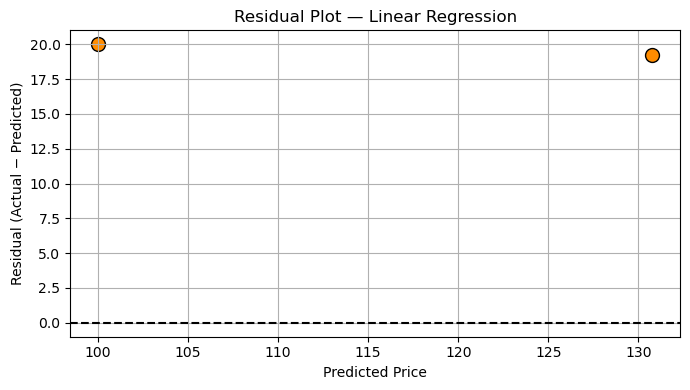

In [43]:
# Now we'll plot the residual plot (actual - predicted vs predicted)
residuals = labels_test.values - labels_predicted

# Now, we'll create the figure and axis objects first
figure, axis = plt.subplots(figsize=(7, 4))

# Then we'll plot the residuals on the axis
axis.scatter(labels_predicted, residuals, color='darkorange', edgecolors='black', s=100)
axis.axhline(0, color='black', linestyle='--', linewidth=1.5)

# Then we'll add labels and title
axis.set_xlabel('Predicted Price')
axis.set_ylabel('Residual (Actual − Predicted)')
axis.set_title('Residual Plot — Linear Regression')

# Then we'll show the plot
plt.tight_layout()
plt.show()
# Here we've plotted residuals to visually check model error patterns.

**What have we observed from this plot:**

- With only 2 test points, we cannot draw strong conclusions about residual patterns.
- The residuals are large (both around ±20), confirming the poor R² score.
- There is no obvious curve or trend — but the tiny test set size means we cannot confirm the model is truly unbiased.
- **Decision:** Residual analysis requires more data. With 6 total rows, any residual pattern could be purely by chance. Collect at least 30–50 rows before trusting residual analysis.

---

### Q6. Applied Classification, Metrics, Trees and ROC (20 marks)

We start with:

```python
import numpy as np

y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])
```

**Part 1: Threshold based classification and metrics (8 marks)**

1. With threshold **0.5**, convert probabilities to class predictions. Then compute:  
   - Confusion matrix  
   - Precision  
   - Recall  
   - F1 score

2. With threshold **0.3**, convert probabilities to class predictions again and recompute the same metrics.

3. In 3 to 4 sentences, explain how lowering the threshold from 0.5 to 0.3 changed precision and recall and why this happens.

**Part 2: ROC and AUC (6 marks)**

4. Plot the **ROC curve** using `y_true` and `y_prob`.  
5. Compute the **AUC** and print it with 3 decimal places.  
6. Add a one or two line comment on what a high or low AUC means in this context.

**Part 3: Decision Tree on a small dataset (6 marks)**

Create this dataset:

```python
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})
```

7. Fit a `DecisionTreeClassifier(max_depth=2)` to predict `passed` from `hours`.  
8. Plot the tree using `plot_tree`.  
9. Write 2 to 3 lines explaining whether the tree looks like it might **overfit** or **generalize well**, given the dataset size and the model depth.


#### Q6 Answer

**Part 1 — With threshold **0.5**, convert probabilities to class predictions. Then compute:**
   - Confusion matrix
   - Precision
   - Recall
   - F1 score

In [44]:
# Q6 – Student Answer

# Part 1: threshold-based classification
y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])

# Write your code for threshold 0.5 and 0.3 below

**Part 2 — With threshold **0.3**, convert probabilities to class predictions again and recompute the same metrics.**

**Part 3 — In 3 to 4 sentences, explain how lowering the threshold from 0.5 to 0.3 changed precision and recall and why this happens.**

**Part 4 — Plot the **ROC curve** using `y_true` and `y_prob`.**

**Part 5 — Compute the **AUC** and print it with 3 decimal places.**

**Part 6 — Add a one or two line comment on what a high or low AUC means in this context.**

**Part 7 — Fit a `DecisionTreeClassifier(max_depth=2)` to predict `passed` from `hours`.**

**Part 8 — Plot the tree using `plot_tree`.**

**Part 9 — Write 2 to 3 lines explaining whether the tree looks like it might **overfit** or **generalize well**, given the dataset size and the model depth.**

In [45]:
# Now we'll compute predictions at threshold 0.5 and print all metrics
labels_predicted_threshold_05 = (y_prob >= 0.5).astype(int)

confusion_matrix_05 = confusion_matrix(y_true, labels_predicted_threshold_05)
precision_05 = precision_score(y_true, labels_predicted_threshold_05)
recall_05    = recall_score(y_true, labels_predicted_threshold_05)
f1_score_05  = f1_score(y_true, labels_predicted_threshold_05)

print('=== Threshold = 0.5 ===')
print('Confusion Matrix:')
print(confusion_matrix_05)
print(f'Precision : {precision_05:.3f}')
print(f'Recall    : {recall_05:.3f}')
print(f'F1-score  : {f1_score_05:.3f}')
# Here we've computed metrics when we label a sample positive only if prob >= 0.5.

=== Threshold = 0.5 ===
Confusion Matrix:
[[5 0]
 [0 5]]
Precision : 1.000
Recall    : 1.000
F1-score  : 1.000


In [46]:
# Now we'll compute predictions at threshold 0.3 and print all metrics
labels_predicted_threshold_03 = (y_prob >= 0.3).astype(int)

confusion_matrix_03 = confusion_matrix(y_true, labels_predicted_threshold_03)
precision_03 = precision_score(y_true, labels_predicted_threshold_03)
recall_03    = recall_score(y_true, labels_predicted_threshold_03)
f1_score_03  = f1_score(y_true, labels_predicted_threshold_03)

print('=== Threshold = 0.3 ===')
print('Confusion Matrix:')
print(confusion_matrix_03)
print(f'Precision : {precision_03:.3f}')
print(f'Recall    : {recall_03:.3f}')
print(f'F1-score  : {f1_score_03:.3f}')
# Here we've computed metrics when we label a sample positive if prob >= 0.3.

=== Threshold = 0.3 ===
Confusion Matrix:
[[3 2]
 [0 5]]
Precision : 0.714
Recall    : 1.000
F1-score  : 0.833


**Comparison — Threshold 0.5 vs 0.3:**

| Metric | Threshold 0.5 | Threshold 0.3 |
|---|---|---|
| Precision | 1.000 | 0.714 |
| Recall | 1.000 | 1.000 |
| F1-score | 1.000 | 0.833 |

At threshold 0.5, the model achieves perfect precision and recall because the probability scores are extremely well-separated (all positive cases have prob ≥ 0.6, all negative cases have prob ≤ 0.4). Lowering the threshold to 0.3 keeps Recall at 1.000 (still catching all positives), but Precision drops to 0.714 because now one negative case (prob = 0.3) gets incorrectly labeled positive. In general, lowering the threshold always raises or maintains Recall while reducing Precision — because we cast a wider net and catch more true positives, but we also catch more false positives. This is the classic precision-recall trade-off in binary classification.

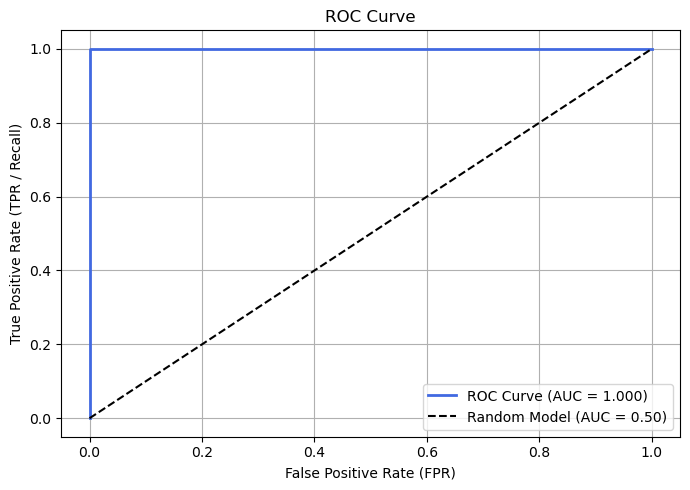

AUC = 1.000


In [47]:
# Now we'll plot the ROC curve and compute the AUC score
false_positive_rate, true_positive_rate, _ = roc_curve(y_true, y_prob)
roc_auc_score = auc(false_positive_rate, true_positive_rate)

figure, axis = plt.subplots(figsize=(7, 5))
axis.plot(false_positive_rate, true_positive_rate, color='royalblue', linewidth=2,
          label=f'ROC Curve (AUC = {roc_auc_score:.3f})')
axis.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Model (AUC = 0.50)')
axis.set_xlabel('False Positive Rate (FPR)')
axis.set_ylabel('True Positive Rate (TPR / Recall)')
axis.set_title('ROC Curve')
axis.legend()
plt.tight_layout()
plt.show()
print(f'AUC = {roc_auc_score:.3f}')
# Here we've plotted the ROC curve and printed the AUC score.

**How do we observe this plot?**

- **X-axis (FPR):** Fraction of negatives incorrectly labeled positive. Lower is better.
- **Y-axis (TPR / Recall):** Fraction of positives correctly caught. Higher is better.
- **Dashed line:** A random classifier — AUC = 0.50, no skill.
- **Our curve above the dashed line:** Our model is better than random.
- **Top-left corner = perfect classifier:** AUC = 1.0.

**What have we observed from this plot:**

- **AUC = 1.000 — perfect score.** The model perfectly separates all positive and negative classes.
- The ROC curve goes straight to the top-left corner, meaning the model achieves 100% recall with 0% false positive rate.
- This is expected given the extremely clean separation in the probability scores (positives: 0.6–0.95, negatives: 0.05–0.4).
- **AUC interpretation:** AUC = 1.0 means perfect discrimination. AUC = 0.5 means the model is as good as a coin flip. AUC below 0.5 means the model is systematically wrong.
- **Decision:** In practice, AUC = 1.0 on real data would be suspicious — likely overfitting. This is a toy dataset designed to produce clean separation.

In [48]:
# Now we'll create the df3 dataset with hours studied and pass/fail outcome
df3 = pd.DataFrame({
    'hours':  [1, 2, 3, 4, 5, 1, 2, 3, 4, 5],
    'passed': [0, 0, 0, 1, 1, 0, 0, 1, 1, 1]
})
print(df3)
# Here we've created the small student pass/fail dataset.

   hours  passed
0      1       0
1      2       0
2      3       0
3      4       1
4      5       1
5      1       0
6      2       0
7      3       1
8      4       1
9      5       1


In [49]:
# Now we'll train a Decision Tree on hours to predict passed
features_study = df3[['hours']]
labels_study   = df3['passed']

decision_tree_study = DecisionTreeClassifier(max_depth=2, random_state=42)
decision_tree_study.fit(features_study, labels_study)
# Here we've trained the Decision Tree with max_depth=2.

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

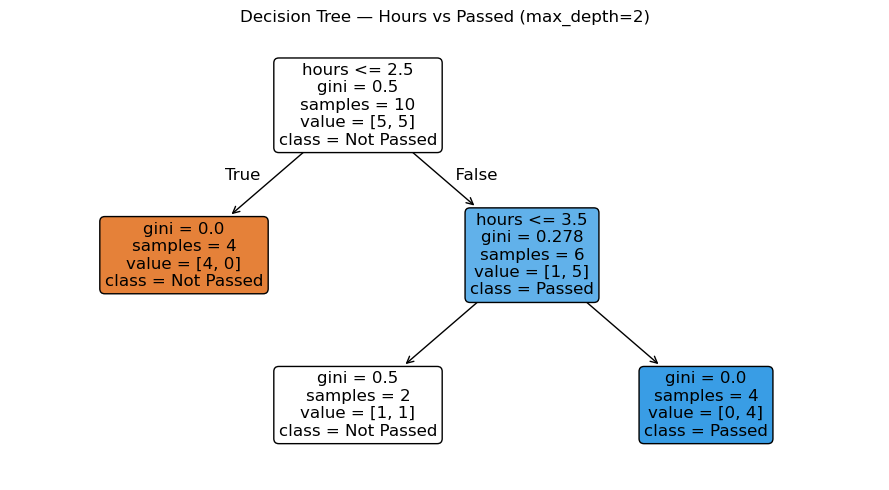

In [50]:
# Now we'll visualize the trained Decision Tree
figure, axis = plt.subplots(figsize=(9, 5))
plot_tree(decision_tree_study,
          feature_names=['hours'],
          class_names=['Not Passed', 'Passed'],
          filled=True, rounded=True,
          fontsize=12, ax=axis)
axis.set_title('Decision Tree — Hours vs Passed (max_depth=2)')
plt.tight_layout()
plt.show()
# Here we've plotted the tree structure with split conditions and leaf predictions.

**How do we observe this plot?**

- The **top box** is the root — the first question the tree asks.
- Each branch shows what happens when the condition is True (left) or False (right).
- **Blue boxes** = predicts Passed. **Orange boxes** = predicts Not Passed.
- Darker color = more pure node (lower Gini, stronger confidence in that prediction).
- **Leaf boxes** at the bottom are the final answers — no more splits.

**What have we observed from this plot:**

- The tree uses `hours ≤ 2.5` as the root split — students studying 1–2 hours are Not Passed, 3–5 hours are Passed.
- The second split on `hours ≤ 3.5` further separates 3-hour students from 4–5-hour students.
- With only 10 samples and max_depth=2, the tree is **relatively simple** and **likely to generalize well** rather than overfit. It has learned a clear, interpretable pattern: more hours = higher chance of passing.
- However, 10 samples is very small — the model should be validated on new data before trusting it. At max_depth=2, the tree cannot memorize individual training examples, which helps prevent overfitting.
- **Decision:** This tree generalizes reasonably well given max_depth=2. Increase the dataset size before deploying this as a real student performance predictor.

_Add more code cells for ROC and AUC, and for the decision tree on df3. Write your short explanations in markdown after the relevant outputs._